<center style="font-size:200px;">
💔
</center>

<h2 align="center">
ML-Based Divorce Risk Prediction and Perceived Causes Analysis Using Demographic, Psychosocial, and Socio-Cultural Factors
</h2>

**Dataset**: Google Form survey - 132 respondents, 17 Likert-scale items on perceived causes of divorce  
**Context**: Nigerian sample, age-skewed (73% aged 20-35), 16.7% self-reported divorce/separation experience

> **Note on Data Quality**: This is a small, survey-based dataset (N=132) which is insufficient for robust ML generalisation.  
> This notebook employs methods appropriate to the data such as: psychometric analysis, statistical group comparisons, clustering, and leave-one-out cross-validation.

### Pipeline Overview
1. Install & Import
2. Data Loading & preprocessing(Cleaning & Encoding)
3. Exploratory Data Analysis (EDA)  
4. Psychometrics analysis(α, EFA)
5. Statistical testing
6. Clustering
7. ML Classification
8. Results interpretation & Summary

## Installation & Importation of Dependencies

In [2]:
import subprocess, sys
pkgs = ["pandas","numpy","scikit-learn","matplotlib","seaborn",
        "scipy","joblib","factor_analyzer==0.5.1"]
subprocess.check_call([sys.executable,"-m","pip","install","--quiet"]+pkgs)
print("Done")

Done


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, spearmanr, kruskal
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import (StratifiedKFold, cross_val_score,
                                     LeaveOneOut, cross_val_predict,
                                     permutation_test_score)
from sklearn.metrics import (roc_auc_score, roc_curve, average_precision_score,
                              brier_score_loss, silhouette_score)
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
import warnings, json
warnings.filterwarnings("ignore")

# Visual style Configuration
DARK='#0A0E17'; CARD='#111827'; ACCENT='#6EE7F7'; GREEN='#34D399'
RED='#F87171'; AMBER='#FCD34D'; TEXT='#F1F5F9'; MUTED='#64748B'
PURPLE='#C084FC'; ROSE='#FB7185'; TEAL='#2DD4BF'
PALETTE=[ACCENT,GREEN,AMBER,RED,PURPLE,ROSE,TEAL,'#60A5FA']
plt.rcParams.update({
    'figure.facecolor':DARK,'axes.facecolor':CARD,'axes.edgecolor':'#1E293B',
    'axes.labelcolor':TEXT,'text.color':TEXT,'xtick.color':MUTED,'ytick.color':MUTED,
    'grid.color':'#1E293B','grid.linewidth':0.5,'font.family':'monospace',
    'font.size':9,'axes.titlesize':11,'axes.titleweight':'bold','axes.titlecolor':TEXT,
})
print("Libraries and styling loaded")

Libraries and styling loaded


## 1. Data Loading & Preprocessing(Cleaning & Encoding)

In [4]:
df_raw = pd.read_csv(
    "Perceived_Cause_of_Divorce_Form Responses.csv",
    encoding = 'latin1')

print(f"Raw-Dataset shape: {df_raw.shape}")
print(f'INSIGHT: There are {df_raw.shape[0]} rows and {df_raw.shape[1]} columns.\n')

print(f"Columns ({len(df_raw.columns)}):")
for c in df_raw.columns:
    print(f"  {c[:70]}")

Raw-Dataset shape: (132, 24)
INSIGHT: There are 132 rows and 24 columns.

Columns (24):
  Timestamp
  Gender
  Age
  Marital Status
  At what age did you get married?
  Length of Marriage (If Applicable)*
  Have you personally experienced divorce or marital separation?  
  Poor communication between spouses is a major cause of divorce?
  Lack of trust between partners contributes to divorce?
  Infidelity is one of the leading causes of divorce?
  Getting married too young can lead to divorce?
    Financial problems often lead to divorce?
  Substance abuse (alcohol/drugs) increases the likelihood of divorce?  
  Non-compactibility of genotype can lead to divorce
    Domestic violence or abuse leads to divorce?  
  Arising Health problems can lead to divorce?
  Lack of support from family can causes couples to divorce?  
  Religious differences contribute to divorce?  
  Career choice can lead to divorce?
  Interference from extended family contributes to divorce.  
  Sexual dissatisfact

In [5]:
df_raw.head(3).T

,0,1,2
Timestamp,1/8/2026 17:22:34,1/8/2026 17:37:40,1/8/2026 17:41:19
Gender,Female,Male,Female
Age,20 - 35years,36 - 45years,20 - 35years
Marital Status,Single,Single,Single
At what age did you get married?,Not Married,Not Married,Not Married
Length of Marriage (If Applicable)*,NaN,NaN,NaN
Have you personally experienced divorce or marital separation?,No,No,Yes
Poor communication between spouses is a major cause of divorce?,Strongly Agree,Strongly Agree,Strongly Agree
Lack of trust between partners contributes to divorce?,Agree,Strongly Agree,Strongly Agree
Infidelity is one of the leading causes of divorce?,Agree,Agree,Strongly Agree


### Insight

The transposed preview provides a clear view of the dataset structure, showing respondents' demographic information alongside their Likert-scale responses on perceived causes of divorce. It also indicates the presence of expected missing values (e.g., for respondents who are not married), which will be addressed during data preprocessing.


In [6]:
# Rename columns 
col_map = {
    'Timestamp': 'timestamp', 'Gender': 'gender', 'Age': 'age',
    'Marital Status': 'marital_status',
    'At what age did you get married?': 'age_married',
    'Length of Marriage (If Applicable)*': 'marriage_length',
    'Have you personally experienced divorce or marital separation?  ': 'experienced_divorce',
    'Poor communication between spouses is a major cause of divorce?': 'q_communication',
    'Lack of trust between partners contributes to divorce?': 'q_trust',
    'Infidelity is one of the leading causes of divorce?': 'q_infidelity',
    'Getting married too young can lead to divorce?': 'q_young_marriage',
    '  Financial problems often lead to divorce?': 'q_financial',
    'Substance abuse (alcohol/drugs) increases the likelihood of divorce?  ': 'q_substance_abuse',
    'Non-compactibility of genotype can lead to divorce': 'q_genotype',
    '  Domestic violence or abuse leads to divorce?  ': 'q_domestic_violence',
    'Arising Health problems can lead to divorce?': 'q_health',
    'Lack of support from family can causes couples to divorce?  ': 'q_family_support',
    'Religious differences contribute to divorce?  ': 'q_religion',
    'Career choice can lead to divorce?': 'q_career',
    'Interference from extended family contributes to divorce.  ': 'q_extended_family',
    'Sexual dissatisfaction can lead to divorce.  ': 'q_sexual',
    'Unrealistic expectations before marriage cause marital breakdown.  ': 'q_expectations',
    'Cultural differences between spouses increase divorce rates.  ': 'q_culture',
    '  Peer influence encourages divorce  ': 'q_peer_influence',
}
df = df_raw.rename(columns=col_map)

# Ordinal encode Likert 
likert_map = {'Strongly Disagree':1,'Disagree':2,'Agree':3,'Strongly Agree':4}
likert_cols = [c for c in df.columns if c.startswith('q_')]
score_cols  = []
for c in likert_cols:
    df[c+'_score'] = df[c].map(likert_map)
    score_cols.append(c+'_score')

short = ['Communication','Trust','Infidelity','Young Marriage','Financial',
         'Substance Abuse','Genotype','Dom. Violence','Health','Family Support',
         'Religion','Career','Ext. Family','Sexual','Expectations','Culture','Peer Influence']

# Demographic encodings 
df['gender_bin']      = (df['gender']=='Male').astype(int)
df['age_ord']         = df['age'].map({'20 - 35years':1,'36 - 45years':2,'46years and above':3})
df['marital_ord']     = df['marital_status'].map({'Single':0,'Married':1,'Divorced':2})
df['divorce_exp_bin'] = (df['experienced_divorce']=='Yes').astype(int)

# Factor composite scores 
df['composite_score']      = df[score_cols].mean(axis=1)
df['factor_interpersonal'] = df[['q_communication_score','q_trust_score',
                                  'q_infidelity_score','q_sexual_score',
                                  'q_expectations_score']].mean(axis=1)
df['factor_socioeconomic'] = df[['q_financial_score','q_career_score',
                                  'q_family_support_score','q_extended_family_score',
                                  'q_peer_influence_score']].mean(axis=1)
df['factor_personal_risk'] = df[['q_substance_abuse_score','q_domestic_violence_score',
                                  'q_young_marriage_score','q_health_score',
                                  'q_genotype_score']].mean(axis=1)
df['factor_sociocultural'] = df[['q_religion_score','q_culture_score']].mean(axis=1)

print(f"Clean shape: {df.shape}")
print(f"Target (divorce experience): {df['divorce_exp_bin'].value_counts().to_dict()}")
print(f"Positive rate: {df['divorce_exp_bin'].mean():.1%}")
df[['gender','age','marital_status','experienced_divorce','composite_score']].describe(include='all')

Clean shape: (132, 50)
Target (divorce experience): {0: 110, 1: 22}
Positive rate: 16.7%


,gender,age,marital_status,experienced_divorce,composite_score
count,132,132,132,132,132.000000
unique,2,3,3,2,NaN
top,Female,20 - 35years,Single,No,NaN
freq,69,97,70,110,NaN
mean,NaN,NaN,NaN,NaN,3.128342
std,NaN,NaN,NaN,NaN,0.339889
min,NaN,NaN,NaN,NaN,2.176471
25%,NaN,NaN,NaN,NaN,2.941176
50%,NaN,NaN,NaN,NaN,3.117647
75%,NaN,NaN,NaN,NaN,3.294118


## 2. Exploratory Data Analysis

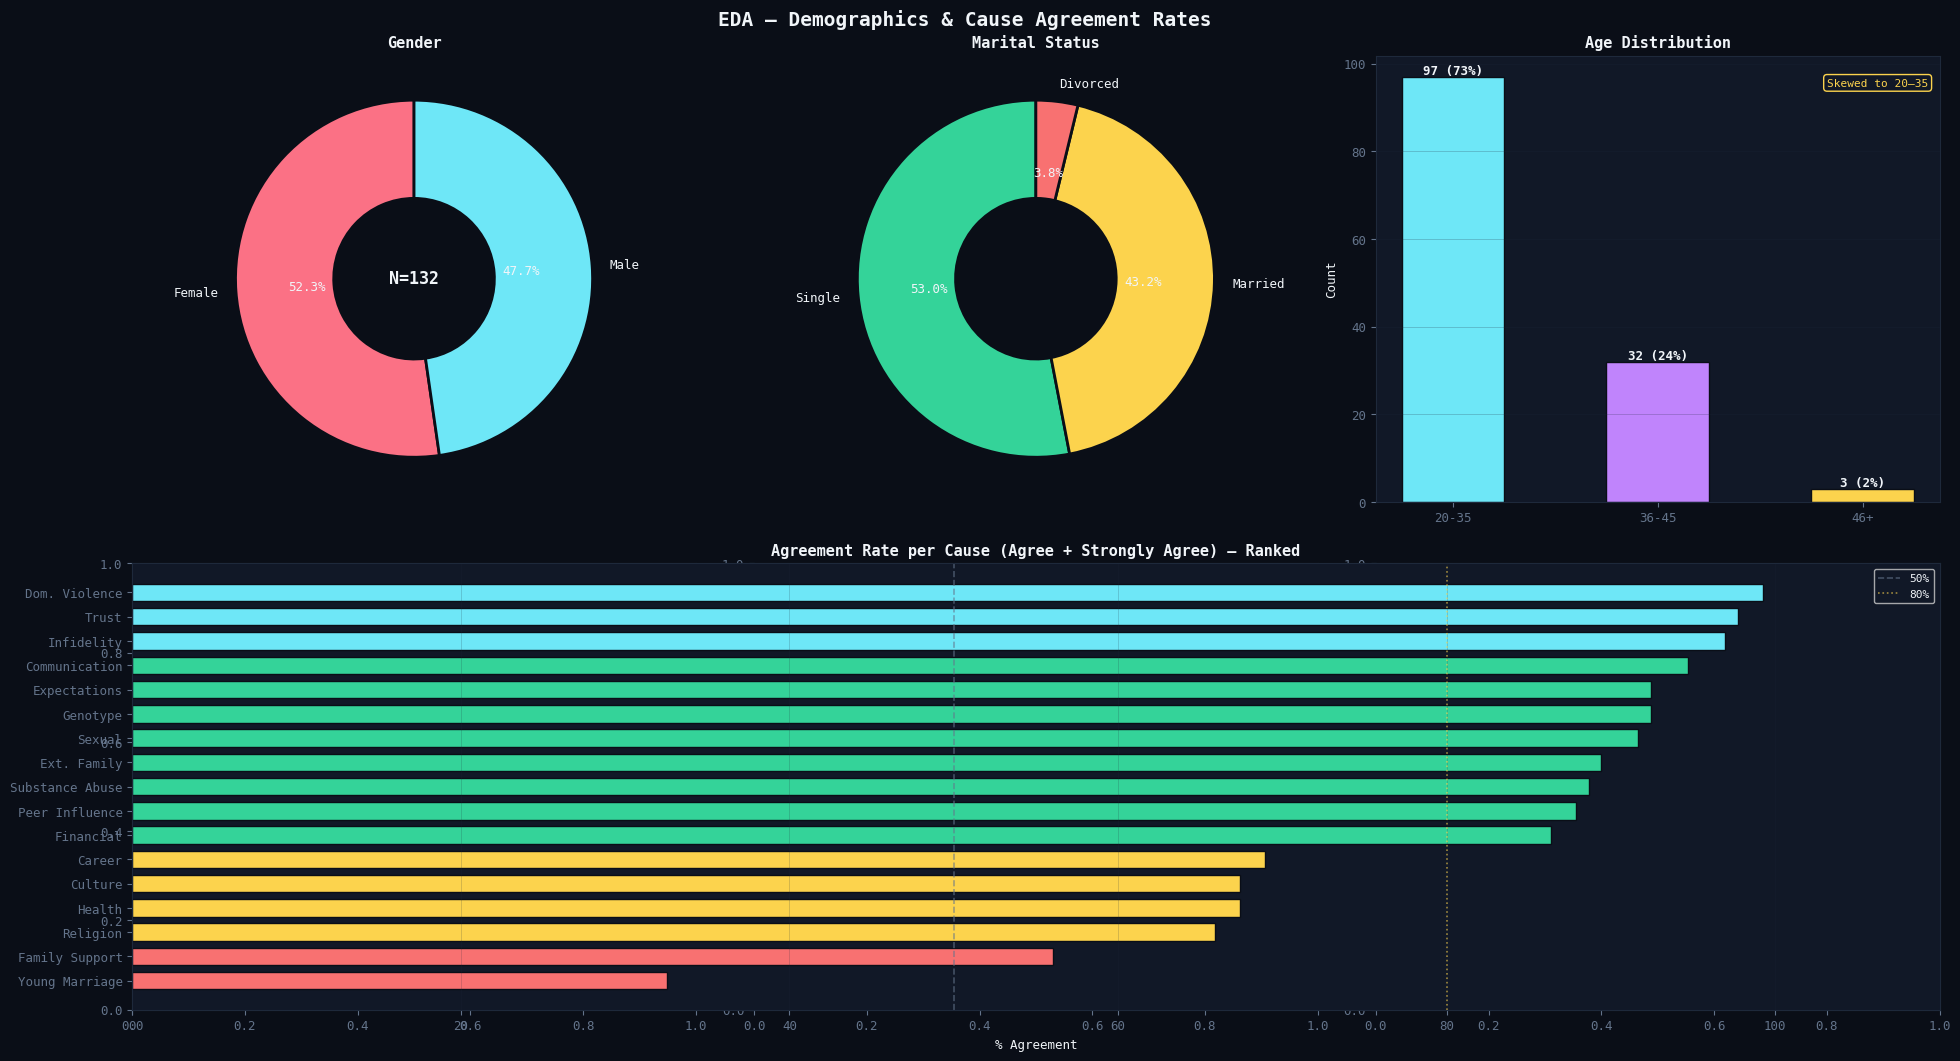

,Cause,Agreement%
7,Dom. Violence,99.2
1,Trust,97.7
2,Infidelity,97.0
0,Communication,94.7
6,Genotype,92.4
14,Expectations,92.4
13,Sexual,91.7
12,Ext. Family,89.4
5,Substance Abuse,88.6
16,Peer Influence,87.9


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11), facecolor=DARK)
fig.suptitle('EDA — Demographics & Cause Agreement Rates', fontsize=14,
             fontweight='bold', color=TEXT)

# Gender donut
ax = axes[0,0]
g = df['gender'].value_counts()
ax.pie(g.values, labels=g.index, colors=[ROSE,ACCENT], autopct='%1.1f%%',
       wedgeprops=dict(width=0.55,edgecolor=DARK,linewidth=2),startangle=90)
ax.text(0,0,f'N={len(df)}',ha='center',va='center',fontsize=12,color=TEXT,fontweight='bold')
ax.set_title('Gender')

# Marital status
ax = axes[0,1]
m = df['marital_status'].value_counts()
ax.pie(m.values, labels=m.index, colors=[GREEN,AMBER,RED], autopct='%1.1f%%',
       wedgeprops=dict(width=0.55,edgecolor=DARK,linewidth=2),startangle=90)
ax.set_title('Marital Status')

# Age distribution
ax = axes[0,2]
age_c = df['age'].value_counts().reindex(['20 - 35years','36 - 45years','46years and above'])
bars = ax.bar(['20-35','36-45','46+'], age_c.values,
              color=[ACCENT,PURPLE,AMBER], edgecolor=DARK, width=0.5)
for b,v in zip(bars,age_c.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
            f'{v} ({v/len(df)*100:.0f}%)', ha='center', fontsize=9, color=TEXT, fontweight='bold')
ax.set_title('Age Distribution'); ax.set_ylabel('Count'); ax.grid(axis='y',alpha=0.3)
ax.text(0.98,0.95,'Skewed to 20–35',transform=ax.transAxes,ha='right',va='top',
        fontsize=8,color=AMBER,bbox=dict(boxstyle='round',facecolor=CARD,edgecolor=AMBER))

# Agreement rate per cause
ax = axes[1,:]
ax = fig.add_subplot(2,1,2)
agree_pcts = [(df[sc]>=3).mean()*100 for sc in score_cols]
sorted_idx = np.argsort(agree_pcts)
ax.barh([short[i] for i in sorted_idx],[agree_pcts[i] for i in sorted_idx],
        color=[RED if v<60 else AMBER if v<80 else GREEN if v<95 else ACCENT
               for v in [agree_pcts[i] for i in sorted_idx]],
        edgecolor=DARK, height=0.72)
ax.axvline(50,color=MUTED,linestyle='--',lw=1.2,alpha=0.6,label='50%')
ax.axvline(80,color=AMBER,linestyle=':',lw=1.2,alpha=0.6,label='80%')
ax.set_title('Agreement Rate per Cause (Agree + Strongly Agree) — Ranked')
ax.set_xlabel('% Agreement'); ax.set_xlim(0,110); ax.legend(fontsize=8)
ax.grid(axis='x', alpha=0.25)

plt.tight_layout()
plt.savefig('div_fig1_eda.png', dpi=120, bbox_inches='tight', facecolor=DARK)
plt.show()

# Print full agreement table
agree_df = pd.DataFrame({'Cause':short,'Agreement%':agree_pcts}).sort_values('Agreement%',ascending=False)
agree_df['Agreement%'] = agree_df['Agreement%'].round(1)
display(agree_df)

## 3. Psychometric Analysis [Cronbach's α & Factor Structure]

In [8]:
# Cronbach's Alpha
def cronbach_alpha(data):
    k = data.shape[1]
    return (k/(k-1)) * (1 - data.var(axis=0,ddof=1).sum() / data.sum(axis=1).var(ddof=1))

X = df[score_cols].values
alpha_full = cronbach_alpha(X)

factor_items = {
    'Interpersonal (n=5)': ['q_communication_score','q_trust_score','q_infidelity_score',
                             'q_sexual_score','q_expectations_score'],
    'Socioeconomic (n=5)': ['q_financial_score','q_career_score','q_family_support_score',
                             'q_extended_family_score','q_peer_influence_score'],
    'Personal Risk (n=5)': ['q_substance_abuse_score','q_domestic_violence_score',
                             'q_young_marriage_score','q_health_score','q_genotype_score'],
    'Sociocultural (n=2)': ['q_religion_score','q_culture_score'],
}

print(f"{'='*55}")
print(f"  Cronbach's Alpha — Full 17-item Scale: α = {alpha_full:.4f}  ({'Good' if alpha_full>=0.7 else 'Acceptable'})")
print(f"{'='*55}")
for name, items in factor_items.items():
    a = cronbach_alpha(df[items].values)
    rating = 'Good' if a>=0.7 else 'Acceptable' if a>=0.6 else 'Poor'
    print(f"  {name:25s}  α = {a:.4f}  ({rating})")

  Cronbach's Alpha — Full 17-item Scale: α = 0.8260  (Good)
  Interpersonal (n=5)        α = 0.6950  (Acceptable)
  Socioeconomic (n=5)        α = 0.6009  (Acceptable)
  Personal Risk (n=5)        α = 0.5170  (Poor)
  Sociocultural (n=2)        α = 0.5580  (Poor)


Eigenvalues: [2.151 0.743 0.634 0.546]
Variance explained: [28.9 10.   8.5  7.4]
Cumulative: [28.9 38.9 47.5 54.8]

4 factors explain 54.8% of variance


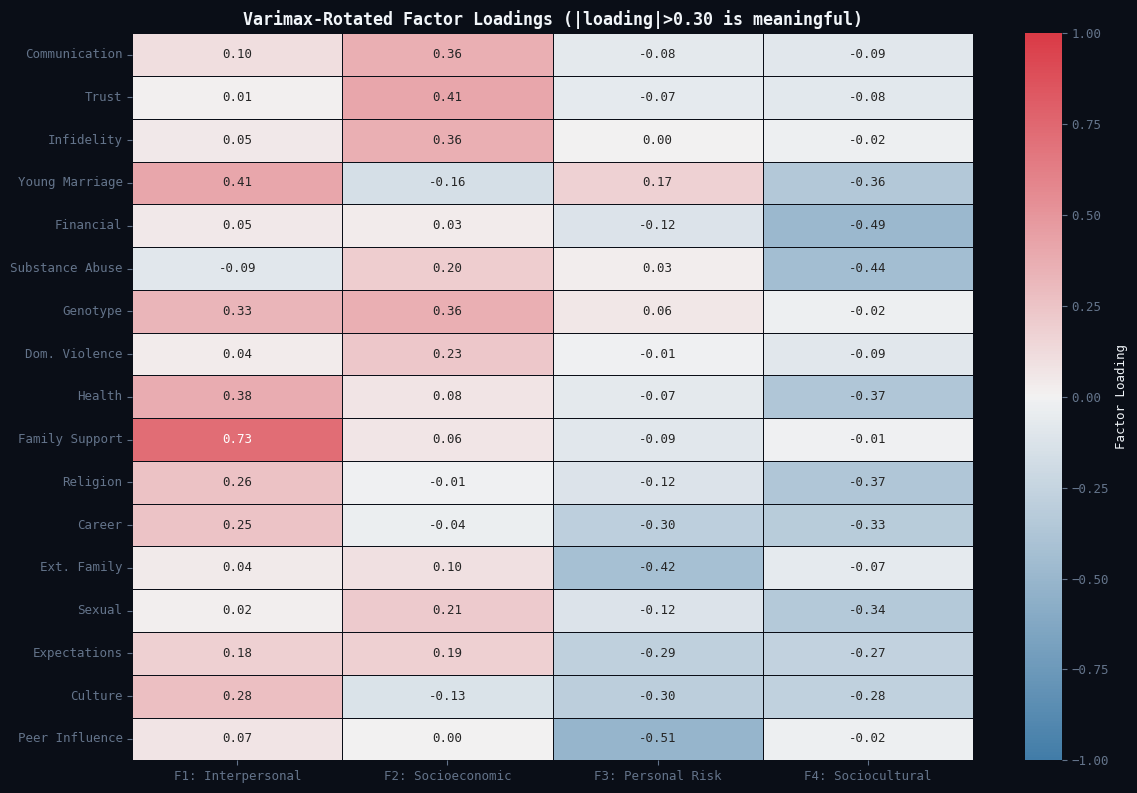

In [9]:
# ── PCA + Varimax rotation (substitute for EFA) ───────────────────
def varimax(loadings, max_iter=1000, tol=1e-6):
    L = loadings.copy(); p,k = L.shape; rotation = np.eye(k)
    for _ in range(max_iter):
        old = rotation.copy()
        for i in range(k):
            for j in range(i+1,k):
                u=L[:,i]**2-L[:,j]**2; v=2*L[:,i]*L[:,j]
                A=np.sum(u);B=np.sum(v);C=np.sum(u**2-v**2);D=2*np.sum(u*v)
                theta=np.arctan2(D-2*A*B/p, C-(A**2-B**2)/p)/4
                rot=np.eye(k); rot[i,i]=rot[j,j]=np.cos(theta)
                rot[i,j]=-np.sin(theta); rot[j,i]=np.sin(theta)
                L=L@rot; rotation=rotation@rot
        if np.max(np.abs(rotation-old))<tol: break
    return L

pca = PCA(n_components=4)
pca.fit(X)
raw_load = pca.components_[:4].T * np.sqrt(pca.explained_variance_[:4])
rotated  = varimax(raw_load)
loadings = pd.DataFrame(rotated, index=short,
                        columns=['F1: Interpersonal','F2: Socioeconomic',
                                 'F3: Personal Risk','F4: Sociocultural'])

print(f"Eigenvalues: {np.round(pca.explained_variance_,3)}")
print(f"Variance explained: {np.round(pca.explained_variance_ratio_*100,1)}")
print(f"Cumulative: {np.round(np.cumsum(pca.explained_variance_ratio_)*100,1)}")
print(f"\n4 factors explain {np.cumsum(pca.explained_variance_ratio_)[3]*100:.1f}% of variance")

# Plot factor loadings
fig, ax = plt.subplots(1, 1, figsize=(12, 8), facecolor=DARK)
sns.heatmap(loadings, ax=ax, cmap=sns.diverging_palette(240,10,as_cmap=True),
            center=0, vmin=-1, vmax=1, annot=True, fmt='.2f',
            annot_kws={'size':9}, linewidths=0.5, linecolor=DARK,
            cbar_kws={'label':'Factor Loading'})
ax.set_title('Varimax-Rotated Factor Loadings (|loading|>0.30 is meaningful)',
             color=TEXT, fontsize=12, fontweight='bold')
ax.set_yticklabels(short, fontsize=9)
plt.tight_layout()
plt.savefig('div_fig2_loadings.png', dpi=120, bbox_inches='tight', facecolor=DARK)
plt.show()

## 4. Statistical Group Comparisons (Mann-Whitney U Tests)

In [10]:
# Mann-Whitney U: Gender & Divorce Experience
results_tests = []
for col, label in zip(score_cols, short):
    male   = df[df['gender']=='Male'][col].values
    female = df[df['gender']=='Female'][col].values
    exp    = df[df['divorce_exp_bin']==1][col].values
    noexp  = df[df['divorce_exp_bin']==0][col].values

    stat_g, p_g = mannwhitneyu(male, female, alternative='two-sided')
    stat_d, p_d = mannwhitneyu(exp,  noexp,  alternative='two-sided')
    r_g = round(1 - 2*stat_g/(len(male)*len(female)), 4)
    r_d = round(1 - 2*stat_d/(len(exp)*len(noexp)),   4)
    results_tests.append({
        'Cause':label,
        'Male Mean':round(np.mean(male),3),'Female Mean':round(np.mean(female),3),
        'Gender p':round(p_g,4),'Gender r':r_g,'Gender Sig':p_g<0.05,
        'Exp Mean':round(np.mean(exp),3),'NoExp Mean':round(np.mean(noexp),3),
        'DivExp p':round(p_d,4),'DivExp r':r_d,'DivExp Sig':p_d<0.05,
    })
tests_df = pd.DataFrame(results_tests)

print(f"Significant gender differences  : {tests_df['Gender Sig'].sum()}/17")
print(f"Significant divorce-exp diffs   : {tests_df['DivExp Sig'].sum()}/17")
print()

# Highlight significant rows
def highlight_sig(row):
    colors = [''] * len(row)
    if row['Gender Sig']:
        for i,col in enumerate(row.index):
            if 'Gender' in col: colors[i] = 'background-color: #1a2a0a; color: #FCD34D'
    if row['DivExp Sig']:
        for i,col in enumerate(row.index):
            if 'DivExp' in col or 'Exp' in col: colors[i] = 'background-color: #2a0a0a; color: #F87171'
    return colors

display(tests_df[['Cause','Male Mean','Female Mean','Gender p','Gender r','Gender Sig',
                  'Exp Mean','NoExp Mean','DivExp p','DivExp r','DivExp Sig']
                ].style.apply(highlight_sig, axis=1).format(precision=4))

Significant gender differences  : 1/17
Significant divorce-exp diffs   : 1/17



,Cause,Male Mean,Female Mean,Gender p,Gender r,Gender Sig,Exp Mean,NoExp Mean,DivExp p,DivExp r,DivExp Sig
0,Communication,3.5400,3.5650,0.7322,0.0299,False,3.5450,3.5550,0.9094,0.0136,False
1,Trust,3.6510,3.6230,0.9579,-0.0046,False,3.5910,3.6450,0.6934,0.0442,False
2,Infidelity,3.4760,3.5650,0.4271,0.0699,False,3.4550,3.5360,0.9860,-0.0025,False
3,Young Marriage,2.3330,2.2030,0.4017,-0.0768,False,2.1820,2.2820,0.5915,0.0661,False
4,Financial,3.2700,2.9570,0.0048,-0.2484,True,3.2270,3.0820,0.4101,-0.0975,False
5,Substance Abuse,3.1900,3.3770,0.0892,0.1560,False,3.5910,3.2270,0.0313,-0.2649,True
6,Genotype,3.3330,3.5510,0.0619,0.1675,False,3.2270,3.4910,0.1388,0.1781,False
7,Dom. Violence,3.7140,3.8550,0.0722,0.1272,False,3.7730,3.7910,0.7934,0.0252,False
8,Health,2.9050,2.7390,0.2178,-0.1146,False,2.7270,2.8360,0.8654,0.0215,False
9,Family Support,2.6190,2.6670,0.7592,0.0292,False,2.5000,2.6730,0.4494,0.0963,False


## 5. Cluster Analysis [Respondent Typologies]

Optimal K = 2  (silhouette=0.1287)


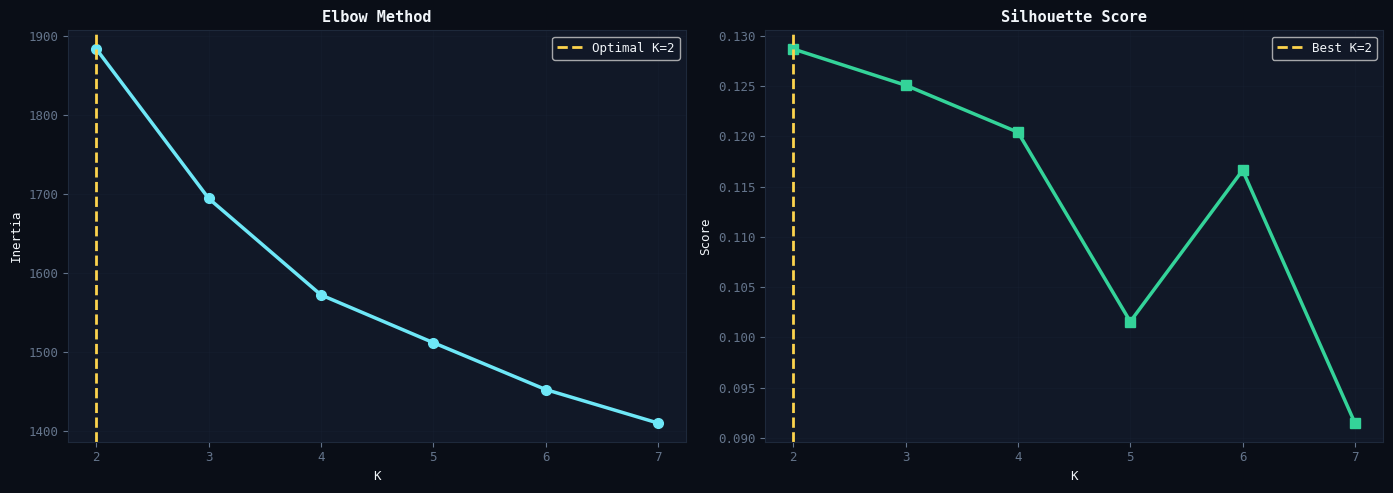

In [11]:
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

# Elbow + Silhouette
k_range = range(2,8)
inertias, silhouettes = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    lab = km.fit_predict(X_sc)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_sc, lab))

best_k = list(k_range)[np.argmax(silhouettes)]
print(f"Optimal K = {best_k}  (silhouette={max(silhouettes):.4f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=DARK)
axes[0].plot(k_range, inertias, 'o-', color=ACCENT, lw=2.5, markersize=7)
axes[0].axvline(best_k, color=AMBER, linestyle='--', lw=2, label=f'Optimal K={best_k}')
axes[0].set_title('Elbow Method'); axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(k_range, silhouettes, 's-', color=GREEN, lw=2.5, markersize=7)
axes[1].axvline(best_k, color=AMBER, linestyle='--', lw=2, label=f'Best K={best_k}')
axes[1].set_title('Silhouette Score'); axes[1].set_xlabel('K'); axes[1].set_ylabel('Score')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig('div_fig3_elbow.png',dpi=120,bbox_inches='tight',facecolor=DARK)
plt.show()

In [12]:
# Final clustering
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=30)
df['cluster'] = km_final.fit_predict(X_sc)

pca2 = PCA(n_components=2); X_pca = pca2.fit_transform(X_sc)
df['pca1'] = X_pca[:,0]; df['pca2'] = X_pca[:,1]

cluster_profiles = df.groupby('cluster')[score_cols].mean()
cluster_profiles.columns = short
cluster_sizes    = df['cluster'].value_counts().sort_index()

print("Cluster sizes:", cluster_sizes.to_dict())
print("\nCluster mean scores:")
display(cluster_profiles.round(3).style.background_gradient(cmap='Blues', axis=None))

Cluster sizes: {0: 88, 1: 44}

Cluster mean scores:


,Communication,Trust,Infidelity,Young Marriage,Financial,Substance Abuse,Genotype,Dom. Violence,Health,Family Support,Religion,Career,Ext. Family,Sexual,Expectations,Culture,Peer Influence
cluster,,,,,,,,,,,,,,,,,
0,3.466000,3.545000,3.443000,2.080000,2.909000,3.102000,3.364000,3.716000,2.557000,2.386000,2.523000,2.511000,2.989000,2.966000,2.977000,2.580000,3.034000
1,3.727000,3.818000,3.682000,2.636000,3.500000,3.659000,3.614000,3.932000,3.341000,3.159000,3.159000,3.273000,3.591000,3.682000,3.750000,3.250000,3.477000


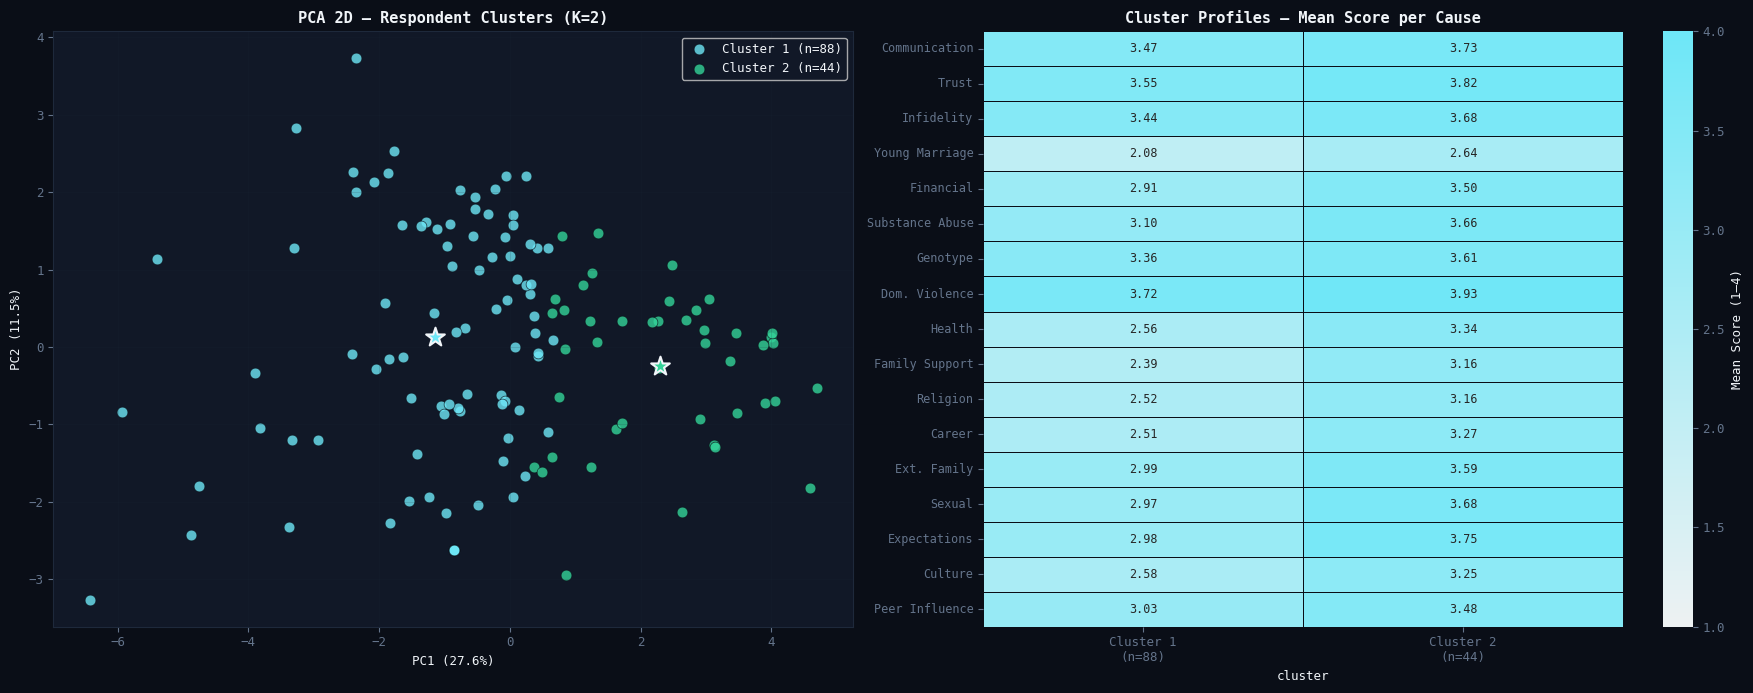

In [13]:
# PCA scatter + cluster heatmap
fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor=DARK)

# PCA scatter
ax = axes[0]
for c in range(best_k):
    mask = df['cluster']==c
    ax.scatter(df[mask]['pca1'], df[mask]['pca2'], color=PALETTE[c],
               s=60, alpha=0.8, edgecolors=DARK, lw=0.5, label=f'Cluster {c+1} (n={mask.sum()})')
    cx,cy = df[mask]['pca1'].mean(), df[mask]['pca2'].mean()
    ax.scatter(cx,cy,color=PALETTE[c],s=200,marker='*',edgecolors=TEXT,lw=1.5,zorder=5)
ax.set_title(f'PCA 2D — Respondent Clusters (K={best_k})')
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(fontsize=9); ax.grid(alpha=0.2)

# Cluster heatmap
ax = axes[1]
sns.heatmap(cluster_profiles.T, ax=ax,
            cmap=sns.light_palette(ACCENT,as_cmap=True),
            annot=True, fmt='.2f', annot_kws={'size':8.5},
            linewidths=0.5, linecolor=DARK, vmin=1, vmax=4,
            cbar_kws={'label':'Mean Score (1–4)'},
            xticklabels=[f'Cluster {c+1}\n(n={cluster_sizes[c]})' for c in range(best_k)])
ax.set_title('Cluster Profiles — Mean Score per Cause')
ax.set_yticklabels(short, fontsize=8.5)

plt.tight_layout(); plt.savefig('div_fig4_clusters.png',dpi=120,bbox_inches='tight',facecolor=DARK)
plt.show()

## 6. ML Classification [Divorce Experience Prediction]

**LOO-CV is used** (leave-one-out cross-validation), being the only unbiased CV strategy at N=132.
- Results near AUC=0.50 confirm the items do not reliably predict personal divorce experience.

In [14]:
factor_cols = ['factor_interpersonal','factor_socioeconomic',
               'factor_personal_risk','factor_sociocultural']
feat_cols = score_cols + ['gender_bin','age_ord','composite_score'] + factor_cols
feat_names = short + ['Gender(M=1)','Age Group','Composite',
                      'F:Interpersonal','F:Socioeconomic','F:Personal Risk','F:Sociocultural']

X_ml = df[feat_cols].values
y_ml = df['divorce_exp_bin'].values
print(f"Feature matrix: {X_ml.shape}")
print(f"Target: {y_ml.sum()} positive / {len(y_ml)} total ({y_ml.mean():.1%})")

models = {
    'LR L2 (C=0.1)': Pipeline([('sc',StandardScaler()),
                    ('clf',LogisticRegression(C=0.1,class_weight='balanced',
                                              max_iter=2000,random_state=42))]),
    'LR L1 (C=0.1)': Pipeline([('sc',StandardScaler()),
                    ('clf',LogisticRegression(C=0.1,class_weight='balanced',penalty='l1',
                                              solver='liblinear',max_iter=2000,random_state=42))]),
    'Random Forest':  Pipeline([('sc',StandardScaler()),
                    ('clf',RandomForestClassifier(n_estimators=200,max_depth=3,
                                                  class_weight='balanced',random_state=42))]),
    'Grad Boosting':  Pipeline([('sc',StandardScaler()),
                    ('clf',GradientBoostingClassifier(n_estimators=100,max_depth=2,
                                                       learning_rate=0.05,random_state=42))]),
    'SVM (RBF)':      Pipeline([('sc',StandardScaler()),
                    ('clf',SVC(C=0.5,kernel='rbf',class_weight='balanced',
                               probability=True,random_state=42))]),
}

loo = LeaveOneOut()
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}
print("\nRunning LOO-CV + 5-fold CV...")
print("-"*65)
for name, model in models.items():
    scores_5   = cross_val_score(model,X_ml,y_ml,cv=cv5,scoring='roc_auc',n_jobs=-1)
    loo_probs  = cross_val_predict(model,X_ml,y_ml,cv=loo,method='predict_proba')[:,1]
    loo_auc    = roc_auc_score(y_ml, loo_probs)
    results[name] = {'cv5':scores_5,'loo_auc':loo_auc,'probs':loo_probs,
                     'auprc':average_precision_score(y_ml,loo_probs)}
    print(f"{name:18s}  LOO-AUC={loo_auc:.4f}  5CV={scores_5.mean():.4f}±{scores_5.std():.4f}")

Feature matrix: (132, 24)
Target: 22 positive / 132 total (16.7%)

Running LOO-CV + 5-fold CV...
-----------------------------------------------------------------
LR L2 (C=0.1)       LOO-AUC=0.6037  5CV=0.5668±0.1964
LR L1 (C=0.1)       LOO-AUC=0.5777  5CV=0.5548±0.0991
Random Forest       LOO-AUC=0.4248  5CV=0.4950±0.1499
Grad Boosting       LOO-AUC=0.4938  5CV=0.5677±0.0997
SVM (RBF)           LOO-AUC=0.3996  5CV=0.4995±0.1866


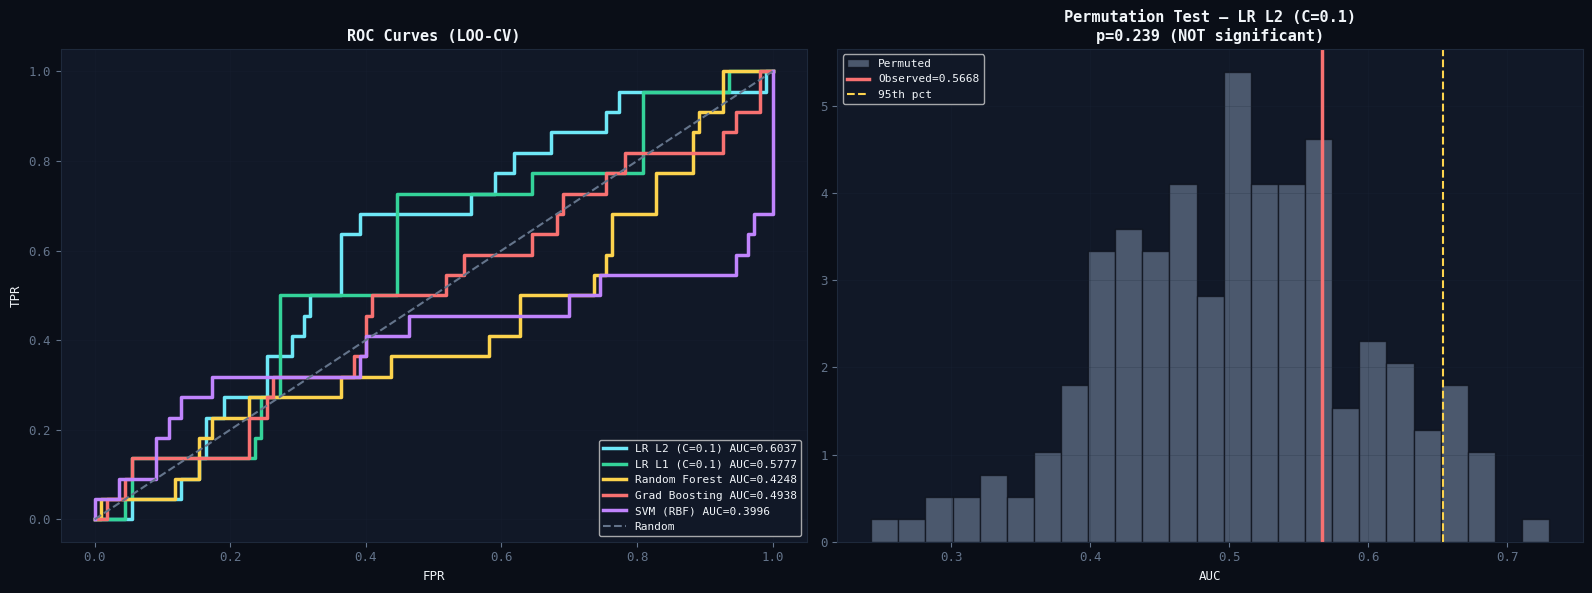


Permutation test p-value: 0.2388
Model is NOT statistically significant (p>0.05)


In [15]:
# ROC curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=DARK)
ax = axes[0]
for i,(name,res) in enumerate(results.items()):
    fpr,tpr,_ = roc_curve(y_ml, res['probs'])
    ax.plot(fpr,tpr,color=PALETTE[i],lw=2.5,label=f"{name} AUC={res['loo_auc']:.4f}")
ax.plot([0,1],[0,1],'--',color=MUTED,lw=1.5,label='Random')
ax.set_title('ROC Curves (LOO-CV)'); ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.legend(fontsize=8,loc='lower right'); ax.grid(alpha=0.25)

# Permutation test on best model
best_name = max(results, key=lambda n: results[n]['loo_auc'])
best_model = models[best_name]
score_obs, perm_scores, pvalue = permutation_test_score(
    best_model,X_ml,y_ml,cv=cv5,scoring='roc_auc',n_permutations=200,
    random_state=42,n_jobs=-1)

ax = axes[1]
ax.hist(perm_scores,bins=25,color=MUTED,alpha=0.7,density=True,edgecolor=DARK,label='Permuted')
ax.axvline(score_obs,color=RED,lw=2.5,label=f'Observed={score_obs:.4f}')
ax.axvline(np.percentile(perm_scores,95),color=AMBER,lw=1.5,linestyle='--',label='95th pct')
ax.set_title(f'Permutation Test — {best_name}\np={pvalue:.3f} ({"NOT " if pvalue>0.05 else ""}significant)')
ax.set_xlabel('AUC'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout(); plt.savefig('div_fig5_roc_perm.png',dpi=120,bbox_inches='tight',facecolor=DARK)
plt.show()
print(f"\nPermutation test p-value: {pvalue:.4f}")
print(f"{'Model is NOT statistically significant (p>0.05)' if pvalue>0.05 else 'Model IS significant!'}")

## 7. Complete Results Summary

<h2 align="center">
KEY FINDINGS ON PERCEIVED CAUSES OF DIVORCE
</h2>

In [16]:
agree_pcts = [(df[sc]>=3).mean()*100 for sc in score_cols]
top5 = sorted(zip(short,agree_pcts),key=lambda x:-x[1])[:5]
bot5 = sorted(zip(short,agree_pcts),key=lambda x:x[1])[:5]

print("\nSCALE RELIABILITY")
def cronbach_alpha(data):
    k=data.shape[1]; return (k/(k-1))*(1-data.var(axis=0,ddof=1).sum()/data.sum(axis=1).var(ddof=1))
alpha_full = cronbach_alpha(df[score_cols].values)
print(f"   Full scale (17 items): α = {alpha_full:.3f}  → {'Good' if alpha_full>=0.7 else 'Acceptable'}")

print("\n↑ TOP 5 (MOST AGREED CAUSES):")
for label,pct in top5: print(f"   {label:25s}  {pct:.1f}%")

print("\n↓  BOTTOM 5 (LEAST AGREED CAUSES):")
for label,pct in bot5: print(f"   {label:25s}  {pct:.1f}%")

print("\n STATISTICAL TESTS:")
print(f"   Gender sig. differences    : {sum(1 for r in tests_df.itertuples() if r._6)}/17")
print(f"   Div. Exp. sig. differences : {sum(1 for r in tests_df.itertuples() if r._11)}/17")

print("\n ML CLASSIFICATION (LOO-CV):")
for name, res in results.items():
    print(f"   {name:18s}  AUC={res['loo_auc']:.4f}")
print(f"   Permutation p-value: {pvalue:.3f} - {'NOT significant' if pvalue>0.05 else 'SIGNIFICANT'}")



SCALE RELIABILITY
   Full scale (17 items): α = 0.826  → Good

↑ TOP 5 (MOST AGREED CAUSES):
   Dom. Violence              99.2%
   Trust                      97.7%
   Infidelity                 97.0%
   Communication              94.7%
   Genotype                   92.4%

↓  BOTTOM 5 (LEAST AGREED CAUSES):
   Young Marriage             32.6%
   Family Support             56.1%
   Religion                   65.9%
   Health                     67.4%
   Culture                    67.4%

 STATISTICAL TESTS:
   Gender sig. differences    : 1/17
   Div. Exp. sig. differences : 1/17

 ML CLASSIFICATION (LOO-CV):
   LR L2 (C=0.1)       AUC=0.6037
   LR L1 (C=0.1)       AUC=0.5777
   Random Forest       AUC=0.4248
   Grad Boosting       AUC=0.4938
   SVM (RBF)           AUC=0.3996
   Permutation p-value: 0.239 - NOT significant


## 8. Recommendations for Future Work

1. **Expand sample size to N≥500.** At N=132 with only 22 divorce-experienced respondents, ML classification was underpowered (permutation p=0.239); this study cannot rule out real predictive signal, only that none was detectable at this scale.

2. **Deliberately oversample divorced and 46+ respondents.** Only 5 of 132 respondents were currently divorced and just 3 were aged 46+, making subgroup analysis on these strata unreliable.

3. **Pair Likert items with open-ended attribution questions.** Quantitative agreement scores can't capture *why* respondents weight causes differently; e.g. the 33% agreement on genotype compatibility likely reflects generational or regional variation in biomedical norms worth exploring qualitatively.

4. **Add socioeconomic and structural variables** (income, education, urban/rural residence, religiosity) to enrich the feature set beyond belief items alone.

5. **Consider a longitudinal design** to distinguish *predictors* of future divorce from *retrospective* causal attribution, which is subject to hindsight bias.

## References

1. DeVellis RF. (2016). *Scale Development: Theory and Applications* (4th ed). Sage.
2. Cronbach LJ. (1951). Coefficient alpha and the internal structure of tests. *Psychometrika*, 16, 297–334.
3. Field A. (2018). *Discovering Statistics Using IBM SPSS Statistics* (5th ed). Sage.
4. Amato PR. (2010). Research on divorce: Continuing trends and new developments. *Journal of Marriage and Family*, 72, 650–666.
5. Lundberg SM & Lee SI. (2017). A unified approach to interpreting model predictions. *NeurIPS*.

> Despite its limitations, this study provides a foundation for future research on divorce perceptions in African contexts through sound methods, appropriate analysis, and transparent reporting.